In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load
import json
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "iframe" # or "notebook_connected"

# Fix for pyLDAvis/Pandas 2.1+ compatibility
if not hasattr(pd.util, 'hash_pandas_object'):
    import pandas.core.util.hashing as hashing
    pd.util.hash_pandas_object = hashing.hash_pandas_object

import pyLDAvis
import pyLDAvis.gensim_models
import gensim
from gensim.models import LdaModel
from gensim.corpora import Dictionary
import pyLDAvis.gensim
from pyLDAvis.utils import NumPyEncoder
pyLDAvis.enable_notebook()

import ipywidgets as widgets
from ipywidgets import Button, Layout
from IPython.display import display, HTML, clear_output

import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_colwidth', None)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session
# Print the installed version of Pandas
# check version of the essential libraries
print('pandas version:', pd.__version__)
print('numpy version:', np.__version__)
print('seaborn version:', sns.__version__)

pandas version: 2.3.3
numpy version: 2.0.2
seaborn version: 0.13.2


In [2]:
data = [
        "Dr Priya Patel in the respiratory clinic was absolutely wonderful. She took time to explain my COPD management plan and made sure I understood every step. The nurse on reception, Karen Thompson, was also very welcoming.",
        "The parking at 45 Albert Street is very limited. I had to walk from the Westfield car park which is difficult at my age.",
        "I had my appointment on 15 January 2026 at 2pm and wasn't seen until after 3:15pm. Dr James Richardson seemed rushed and didn't listen to my concerns about the medication side effects. I called the clinic at 07 3456 7890 twice before my appointment to ask about preparation and nobody answered. My wife Angela Chen had a much better experience at the Chermside Day Surgery last month.",
        "The physiotherapist Michael was great. He gave me a detailed home exercise program after my knee surgery and followed up via email at susan.obrien82@gmail.com to check on my progress. Very impressed with that level of care.",
        "The online booking system could be easier to use. I ended up calling reception to book because I couldn't figure out the Zedoc portal. I was referred by Dr Nguyen at the Ipswich Hospital and the transition was smooth.",
        "Nurse Rebecca Taylor in the diabetes clinic was exceptional. She spent over 40 minutes with me going through my HbA1c results and adjusting my insulin plan. She also coordinated with my GP Dr Samantha Lee at the Toowoomba Medical Practice to ensure consistent care.",
        "Dr Patel is always thorough and patient. She remembers details from previous visits which makes me feel valued.",
        "I'm 81 years old and find the forms quite difficult to fill in. My daughter Sarah Fitzpatrick usually helps me but she wasn't available this time. Could you offer some assistance at the front desk for elderly patients? Also my Medicare number is 2345 67890 1 and I think there was a billing error on my last visit on 28 January 2026.",
        "The midwifery team, especially Lisa and Jenny, were amazing throughout my pregnancy. They made me feel safe and supported. The antenatal classes at the centre on George Street were also excellent.",
        "It would be nice to have later appointment slots. As a working mum I find it hard to attend before 4pm. My employer at Bright Horizons Childcare is not always flexible with time off. I recommended this clinic to my sister-in-law Patricia Nakamura who is expecting in July.",
        "The new blood collection nurse, Daniel Kim, was very skilled. Best blood draw I've had - barely felt it. He mentioned he previously worked at the Royal Brisbane and Women's Hospital.",
        "The results portal is confusing. I had to call Dr Richardson's office at 07 3456 7891 to get my pathology explained because I couldn't understand the online report.",
        "Dr Patel and Nurse Rebecca were both excellent. They were respectful of my cultural needs and ensured a female practitioner was available for my examination. This was very important to me.",
        "The interpreter service was not available on 4 March 2026 when my mother attended. She speaks Arabic and struggled to communicate her symptoms. Please ensure interpreters are booked in advance. My mother Zahra Al-Rashid (patient ID PAT-91603) would like to provide feedback separately. Can someone contact her at fatima.alrashid@outlook.com to arrange an Arabic-language survey?",
        "Outstanding mental health support from psychologist Dr Amanda Clarke. She helped me develop coping strategies after my workplace incident at BHP Mitsubishi Alliance in Mount Isa last year. The telehealth option made it possible to continue sessions when I was FIFO.",
        "The mental health waiting list is too long. I was referred on 15 November 2025 and didn't get my first appointment until 8 January 2026. That's nearly 8 weeks.",
        "The wound care nurse Jacinta was thorough and gentle. She explained the healing process for my post-surgical wound clearly and gave me written instructions to take home.",
        "I received a reminder SMS from Zedoc to complete this survey but the link didn't work on my Samsung phone. I had to use my husband David Tran's iPhone instead. The SMS came from number 0437 123 456. I was transferred from Logan Hospital after my surgery there on 2 March 2026. The handover between hospitals could have been smoother - my medication list wasn't updated correctly.",
        "The entire cardiology team is first-rate. Dr Richardson personally called me at home on 0478 234 567 to discuss my stress test results. That kind of proactive communication is rare and very reassuring.",
        "The car park needs more disabled bays. I have a temporary mobility permit after my cardiac rehab and struggled to find a spot on 20 March 2026. My cardiologist at the Prince Charles Hospital, Dr Andrew Walsh, also coordinates with Dr Richardson here which gives me great confidence in my care plan."
       ]

In [3]:
df = pd.DataFrame({'text': data})
df.head(20)

,text
0,"Dr Priya Patel in the respiratory clinic was absolutely wonderful. She took time to explain my COPD management plan and made sure I understood every step. The nurse on reception, Karen Thompson, was also very welcoming."
1,The parking at 45 Albert Street is very limited. I had to walk from the Westfield car park which is difficult at my age.
2,I had my appointment on 15 January 2026 at 2pm and wasn't seen until after 3:15pm. Dr James Richardson seemed rushed and didn't listen to my concerns about the medication side effects. I called the clinic at 07 3456 7890 twice before my appointment to ask about preparation and nobody answered. My wife Angela Chen had a much better experience at the Chermside Day Surgery last month.
3,The physiotherapist Michael was great. He gave me a detailed home exercise program after my knee surgery and followed up via email at susan.obrien82@gmail.com to check on my progress. Very impressed with that level of care.
4,The online booking system could be easier to use. I ended up calling reception to book because I couldn't figure out the Zedoc portal. I was referred by Dr Nguyen at the Ipswich Hospital and the transition was smooth.
5,Nurse Rebecca Taylor in the diabetes clinic was exceptional. She spent over 40 minutes with me going through my HbA1c results and adjusting my insulin plan. She also coordinated with my GP Dr Samantha Lee at the Toowoomba Medical Practice to ensure consistent care.
6,Dr Patel is always thorough and patient. She remembers details from previous visits which makes me feel valued.
7,I'm 81 years old and find the forms quite difficult to fill in. My daughter Sarah Fitzpatrick usually helps me but she wasn't available this time. Could you offer some assistance at the front desk for elderly patients? Also my Medicare number is 2345 67890 1 and I think there was a billing error on my last visit on 28 January 2026.
8,"The midwifery team, especially Lisa and Jenny, were amazing throughout my pregnancy. They made me feel safe and supported. The antenatal classes at the centre on George Street were also excellent."
9,It would be nice to have later appointment slots. As a working mum I find it hard to attend before 4pm. My employer at Bright Horizons Childcare is not always flexible with time off. I recommended this clinic to my sister-in-law Patricia Nakamura who is expecting in July.


# Text Analysis

In [4]:
import nltk
import subprocess

# Download and unzip wordnet
try:
    nltk.data.find('wordnet.zip')
except:
    nltk.download('wordnet', download_dir='/kaggle/working/')
    command = "unzip /kaggle/working/corpora/wordnet.zip -d /kaggle/working/corpora"
    subprocess.run(command.split())
    nltk.data.path.append('/kaggle/working/')

# Now you can import the NLTK resources as usual
from nltk.corpus import wordnet

[nltk_data] Downloading package wordnet to /kaggle/working/...


Archive:  /kaggle/working/corpora/wordnet.zip
   creating: /kaggle/working/corpora/wordnet/
  inflating: /kaggle/working/corpora/wordnet/lexnames  
  inflating: /kaggle/working/corpora/wordnet/data.verb  
  inflating: /kaggle/working/corpora/wordnet/index.adv  
  inflating: /kaggle/working/corpora/wordnet/adv.exc  
  inflating: /kaggle/working/corpora/wordnet/index.verb  
  inflating: /kaggle/working/corpora/wordnet/cntlist.rev  
  inflating: /kaggle/working/corpora/wordnet/data.adj  
  inflating: /kaggle/working/corpora/wordnet/index.adj  
  inflating: /kaggle/working/corpora/wordnet/LICENSE  
  inflating: /kaggle/working/corpora/wordnet/citation.bib  
  inflating: /kaggle/working/corpora/wordnet/noun.exc  
  inflating: /kaggle/working/corpora/wordnet/verb.exc  
  inflating: /kaggle/working/corpora/wordnet/README  
  inflating: /kaggle/working/corpora/wordnet/index.sense  
  inflating: /kaggle/working/corpora/wordnet/data.noun  
  inflating: /kaggle/working/corpora/wordnet/data.adv  


## Textual Data Cleaning

In [5]:
# define a function to normalize the review text (remove stopwords, punctuation, lemmatization)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize 
import re

lemmatizer = WordNetLemmatizer()

stopwords = stopwords.words('english')
stopwords = stopwords 
pattern = r'[^\w\s]' #  matches any character that is not a word character (\w) or whitespace (\s)

def text_normalization(text):
    if not isinstance(text, str):
        return ''
    texts = re.sub(pattern, '', text)
    tokens = word_tokenize(texts)
    fil_tokens = [token for token in tokens if token.lower() not in stopwords]
    fil_tokens_lemma = [lemmatizer.lemmatize(token) for token in fil_tokens]
    joined_text = ' '.join(map(str, fil_tokens_lemma))
    return joined_text

In [6]:
# insert a new column for the normalized text data
df['normalized_text'] = df['text'].apply(lambda x: text_normalization(x))
df.head(20)

,text,normalized_text
0,"Dr Priya Patel in the respiratory clinic was absolutely wonderful. She took time to explain my COPD management plan and made sure I understood every step. The nurse on reception, Karen Thompson, was also very welcoming.",Dr Priya Patel respiratory clinic absolutely wonderful took time explain COPD management plan made sure understood every step nurse reception Karen Thompson also welcoming
1,The parking at 45 Albert Street is very limited. I had to walk from the Westfield car park which is difficult at my age.,parking 45 Albert Street limited walk Westfield car park difficult age
2,I had my appointment on 15 January 2026 at 2pm and wasn't seen until after 3:15pm. Dr James Richardson seemed rushed and didn't listen to my concerns about the medication side effects. I called the clinic at 07 3456 7890 twice before my appointment to ask about preparation and nobody answered. My wife Angela Chen had a much better experience at the Chermside Day Surgery last month.,appointment 15 January 2026 2pm wasnt seen 315pm Dr James Richardson seemed rushed didnt listen concern medication side effect called clinic 07 3456 7890 twice appointment ask preparation nobody answered wife Angela Chen much better experience Chermside Day Surgery last month
3,The physiotherapist Michael was great. He gave me a detailed home exercise program after my knee surgery and followed up via email at susan.obrien82@gmail.com to check on my progress. Very impressed with that level of care.,physiotherapist Michael great gave detailed home exercise program knee surgery followed via email susanobrien82gmailcom check progress impressed level care
4,The online booking system could be easier to use. I ended up calling reception to book because I couldn't figure out the Zedoc portal. I was referred by Dr Nguyen at the Ipswich Hospital and the transition was smooth.,online booking system could easier use ended calling reception book couldnt figure Zedoc portal referred Dr Nguyen Ipswich Hospital transition smooth
5,Nurse Rebecca Taylor in the diabetes clinic was exceptional. She spent over 40 minutes with me going through my HbA1c results and adjusting my insulin plan. She also coordinated with my GP Dr Samantha Lee at the Toowoomba Medical Practice to ensure consistent care.,Nurse Rebecca Taylor diabetes clinic exceptional spent 40 minute going HbA1c result adjusting insulin plan also coordinated GP Dr Samantha Lee Toowoomba Medical Practice ensure consistent care
6,Dr Patel is always thorough and patient. She remembers details from previous visits which makes me feel valued.,Dr Patel always thorough patient remembers detail previous visit make feel valued
7,I'm 81 years old and find the forms quite difficult to fill in. My daughter Sarah Fitzpatrick usually helps me but she wasn't available this time. Could you offer some assistance at the front desk for elderly patients? Also my Medicare number is 2345 67890 1 and I think there was a billing error on my last visit on 28 January 2026.,Im 81 year old find form quite difficult fill daughter Sarah Fitzpatrick usually help wasnt available time Could offer assistance front desk elderly patient Also Medicare number 2345 67890 1 think billing error last visit 28 January 2026
8,"The midwifery team, especially Lisa and Jenny, were amazing throughout my pregnancy. They made me feel safe and supported. The antenatal classes at the centre on George Street were also excellent.",midwifery team especially Lisa Jenny amazing throughout pregnancy made feel safe supported antenatal class centre George Street also excellent
9,It would be nice to have later appointment slots. As a working mum I find it hard to attend before 4pm. My employer at Bright Horizons Childcare is not always flexible with time off. I recommended this clinic to my sister-in-law Patricia Nakamura who is expecting in July.,would nice later appointment slot working mum find hard attend 4pm employer Bright Horizons Childcare always flexible time

# Exploratory Data Analysis (EDA)

## 1. Sentiment Scores

In [7]:
!pip3 install torch torchvision torchaudio

In [8]:
!pip install transformers

In [9]:
import torch
from transformers import AutoModelForSequenceClassification, AutoConfig
#from transformers import TFAutoModelForSequenceClassification
from transformers import AutoTokenizer, Trainer
from transformers import BertTokenizer, BertForSequenceClassification, BertConfig
import numpy 
import numpy as np
from scipy.special import softmax
import tensorflow as tf

2026-04-20 00:56:36.183074: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776646596.416148      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776646596.481729      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776646597.025525      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776646597.025607      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776646597.025612      55 computation_placer.cc:177] computation placer alr

In [10]:
# load tokenizer and model, create trainer
MODEL = "nlptown/bert-base-multilingual-uncased-sentiment"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
config = AutoConfig.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)
trainer = Trainer(model=model)

config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [11]:
def sentiment_labels(text):
    encoded_input = tokenizer(text, padding=True,truncation=True,max_length=512,return_tensors='pt')
    output = model(**encoded_input)
    # Use .squeeze() to remove the batch dimension safely
    scores = output[0][0].detach().numpy()
    scores = softmax(scores)
    ranking = np.argsort(scores)
    ranking = ranking[::-1]
    return config.id2label[ranking[0]]

In [12]:
df['rating'] = df['text'].apply(lambda x: sentiment_labels(x))
df.head(20)

,text,normalized_text,rating
0,"Dr Priya Patel in the respiratory clinic was absolutely wonderful. She took time to explain my COPD management plan and made sure I understood every step. The nurse on reception, Karen Thompson, was also very welcoming.",Dr Priya Patel respiratory clinic absolutely wonderful took time explain COPD management plan made sure understood every step nurse reception Karen Thompson also welcoming,5 stars
1,The parking at 45 Albert Street is very limited. I had to walk from the Westfield car park which is difficult at my age.,parking 45 Albert Street limited walk Westfield car park difficult age,2 stars
2,I had my appointment on 15 January 2026 at 2pm and wasn't seen until after 3:15pm. Dr James Richardson seemed rushed and didn't listen to my concerns about the medication side effects. I called the clinic at 07 3456 7890 twice before my appointment to ask about preparation and nobody answered. My wife Angela Chen had a much better experience at the Chermside Day Surgery last month.,appointment 15 January 2026 2pm wasnt seen 315pm Dr James Richardson seemed rushed didnt listen concern medication side effect called clinic 07 3456 7890 twice appointment ask preparation nobody answered wife Angela Chen much better experience Chermside Day Surgery last month,1 star
3,The physiotherapist Michael was great. He gave me a detailed home exercise program after my knee surgery and followed up via email at susan.obrien82@gmail.com to check on my progress. Very impressed with that level of care.,physiotherapist Michael great gave detailed home exercise program knee surgery followed via email susanobrien82gmailcom check progress impressed level care,5 stars
4,The online booking system could be easier to use. I ended up calling reception to book because I couldn't figure out the Zedoc portal. I was referred by Dr Nguyen at the Ipswich Hospital and the transition was smooth.,online booking system could easier use ended calling reception book couldnt figure Zedoc portal referred Dr Nguyen Ipswich Hospital transition smooth,4 stars
5,Nurse Rebecca Taylor in the diabetes clinic was exceptional. She spent over 40 minutes with me going through my HbA1c results and adjusting my insulin plan. She also coordinated with my GP Dr Samantha Lee at the Toowoomba Medical Practice to ensure consistent care.,Nurse Rebecca Taylor diabetes clinic exceptional spent 40 minute going HbA1c result adjusting insulin plan also coordinated GP Dr Samantha Lee Toowoomba Medical Practice ensure consistent care,5 stars
6,Dr Patel is always thorough and patient. She remembers details from previous visits which makes me feel valued.,Dr Patel always thorough patient remembers detail previous visit make feel valued,5 stars
7,I'm 81 years old and find the forms quite difficult to fill in. My daughter Sarah Fitzpatrick usually helps me but she wasn't available this time. Could you offer some assistance at the front desk for elderly patients? Also my Medicare number is 2345 67890 1 and I think there was a billing error on my last visit on 28 January 2026.,Im 81 year old find form quite difficult fill daughter Sarah Fitzpatrick usually help wasnt available time Could offer assistance front desk elderly patient Also Medicare number 2345 67890 1 think billing error last visit 28 January 2026,2 stars
8,"The midwifery team, especially Lisa and Jenny, were amazing throughout my pregnancy. They made me feel safe and supported. The antenatal classes at the centre on George Street were also excellent.",midwifery team especially Lisa Jenny amazing throughout pregnancy made feel safe supported antenatal class centre George Street also excellent,5 stars
9,It would be nice to have later appointment slots. As a working mum I find it hard to attend before 4pm. My employer at Bright Horizons Childcare is not always flexible with time off. I recommended this clinic to my sister-in-law Patricia Nakamura who is expecting in July.,would nice later appointment slot working mu

In [13]:
# check the distribution of the variable 'rating'
rating = df['rating'].value_counts().sort_index()
rating_df = pd.DataFrame(rating).reset_index()
rating_df.columns = ['Rating', 'Count']

fig = px.bar(rating_df, 
             x='Rating', y='Count', 
             #width=800, height=500, 
             template='gridon', 
             title='Review Rating')

fig.update_layout(
    xaxis = dict(
        title = 'Review Rating'
    ),
    yaxis = dict(
        title = 'Count'
    )
    
)

## 2. Customer Feedback: Text Analysis and Preprocessing with spaCy

Topic analysis, or topic modeling, is a method in natural language processing that identifies hidden themes in text by grouping words and documents into topics using unsupervised learning techniques.

### What is Topic Analysis?

Topic analysis is a text mining technique used to uncover latent themes or topics within a large corpus of text. It is an unsupervised machine learning approach, meaning it does not require pre-labeled data. Instead, it identifies patterns of word co-occurrence and clusters them into topics, which represent the main ideas or themes in the text. This process helps in summarizing, organizing, and understanding large volumes of unstructured text data. 

### How Topic Analysis Works

Text Preprocessing: Before analysis, text is cleaned and standardized. Common steps include converting text to lowercase, removing stopwords, expanding contractions, and lemmatizing words to their base forms. 

#### a. Document-Term Matrix (DTM): 

Text is transformed into a matrix where rows represent documents and columns represent terms, with values indicating term frequency or TF-IDF (term frequency, inverse document frequency) scores. 

#### b. Topic Modeling Algorithms: 

Popular algorithms include:

* **Latent Dirichlet Allocation (LDA)**: Treats each document as a mixture of topics and each topic as a mixture of words, allowing overlapping content across documents. 

* **Meaning Extraction Method (MEM)**: Identifies clusters of co-occurring words to reveal underlying themes, often used in psychological and social science research. 

#### c. Interpretation: 

Each topic is represented by a set of keywords, and documents are assigned topic proportions, showing how much each topic contributes to the document. 

#### d. Applications of Topic Analysis

* **Document Summarization**: Extracting key themes from large documents.

* **Information Retrieval**: Enhancing search engines by understanding query context.

* **Customer Feedback Analysis**: Identifying common themes in reviews or surveys.

* **Recommendation Systems**: Suggesting content based on topic similarity. 

* **Business Intelligence**: Rapidly analyzing unstructured data to detect trends or challenges. 

#### e. Tools and Libraries

* **Python**: gensim, scikit-learn, spaCy, NLTK, and Jupyter Notebook for preprocessing, modeling, and visualization. 

* **R**: topicmodels, tidytext, dplyr, and ggplot2 for building and visualizing topic models. 

#### f. Key Considerations

* The number of topics must be chosen carefully to balance interpretability and granularity.

* Preprocessing quality significantly affects model performance.

* Topic models provide probabilistic associations, not definitive labels, so human interpretation is often required.

In summary, **topic analysis transforms unstructured text into structured insights**, enabling researchers and businesses to efficiently understand and act on large volumes of textual data. It is widely used in NLP, social sciences, marketing, and information retrieval.

## Computational Linguistics: POS-Tagging — (Part Of Speech)

We will be checking out `spaCy`, an industrial-strength Natural Language Processing library, to clean and preprocess our text data.

Let’s explore some of the powerful linguistic analysis features that spaCy offers. These features can provide deeper insights into our text and can be useful for more advanced NLP tasks beyond topic modeling.

POS tagging identifies the grammatical parts of speech for each word in a sentence. This is crucial for understanding the role each word plays in the sentence structure.

Understanding POS tags can help in tasks like feature extraction for machine learning models or in creating more sophisticated text processing rules.

In [14]:
import os

import spacy 
from spacy import displacy

import gensim
from gensim.corpora import Dictionary
from gensim.models import LdaModel, CoherenceModel, LsiModel, HdpModel

In [15]:
nlp = spacy.load('en_core_web_sm')

my_stop_words = ['say', '\s', 'mr', 'Mr', 'said', 'says', 'saying', 'today', 'be']

for stopword in my_stop_words:
    lexeme = nlp.vocab[stopword]
    lexeme.is_stop = True

In [16]:
for i, text in enumerate(data):
    sent = nlp(text)
    print(f" * sentece: {i + 1}: {text}")
    ans = list()
    for token in sent:
        if token.pos_:
            tmp = '["' + token.text + '"_"' + token.pos_ + '"_"' + token.tag_ + '"]'
        else:
            tmp = '["' + token.text + '"]'
        ans.append(tmp)
    print(':'.join(ans))
    print('\n')

 * sentece: 1: Dr Priya Patel in the respiratory clinic was absolutely wonderful. She took time to explain my COPD management plan and made sure I understood every step. The nurse on reception, Karen Thompson, was also very welcoming.
["Dr"_"PROPN"_"NNP"]:["Priya"_"PROPN"_"NNP"]:["Patel"_"PROPN"_"NNP"]:["in"_"ADP"_"IN"]:["the"_"DET"_"DT"]:["respiratory"_"ADJ"_"JJ"]:["clinic"_"NOUN"_"NN"]:["was"_"AUX"_"VBD"]:["absolutely"_"ADV"_"RB"]:["wonderful"_"ADJ"_"JJ"]:["."_"PUNCT"_"."]:["She"_"PRON"_"PRP"]:["took"_"VERB"_"VBD"]:["time"_"NOUN"_"NN"]:["to"_"PART"_"TO"]:["explain"_"VERB"_"VB"]:["my"_"PRON"_"PRP$"]:["COPD"_"NOUN"_"NN"]:["management"_"NOUN"_"NN"]:["plan"_"NOUN"_"NN"]:["and"_"CCONJ"_"CC"]:["made"_"VERB"_"VBD"]:["sure"_"ADJ"_"JJ"]:["I"_"PRON"_"PRP"]:["understood"_"VERB"_"VBD"]:["every"_"DET"_"DT"]:["step"_"NOUN"_"NN"]:["."_"PUNCT"_"."]:["The"_"DET"_"DT"]:["nurse"_"NOUN"_"NN"]:["on"_"ADP"_"IN"]:["reception"_"NOUN"_"NN"]:[","_"PUNCT"_","]:["Karen"_"PROPN"_"NNP"]:["Thompson"_"PROPN"_"NNP"]

## NER-Tagging — (Named Entity Recognition)

NER identifies and classifies named entities (like persons, organizations, locations) in text. This is valuable for information extraction and can provide context for topic modeling.

NER can be particularly useful when you want to focus on specific types of entities in your topic modeling or when you want to exclude certain entity types.

In [17]:
for i, text in enumerate(data):
    sent = nlp(text)
    print(f" * sentece: {i + 1}: {text}")
    ans = list()
    for token in sent:
        if token.ent_type_:
            tmp = '["' + token.text + '"_"' + token.ent_type_ + '"]'
        else:
            tmp = '["' + token.text + '"]'
        ans.append(tmp)
    print(':'.join(ans))
    print('\n')

 * sentece: 1: Dr Priya Patel in the respiratory clinic was absolutely wonderful. She took time to explain my COPD management plan and made sure I understood every step. The nurse on reception, Karen Thompson, was also very welcoming.
["Dr"]:["Priya"_"PERSON"]:["Patel"_"PERSON"]:["in"]:["the"]:["respiratory"]:["clinic"]:["was"]:["absolutely"]:["wonderful"]:["."]:["She"]:["took"]:["time"]:["to"]:["explain"]:["my"]:["COPD"_"ORG"]:["management"]:["plan"]:["and"]:["made"]:["sure"]:["I"]:["understood"]:["every"]:["step"]:["."]:["The"]:["nurse"]:["on"]:["reception"]:[","]:["Karen"_"PERSON"]:["Thompson"_"PERSON"]:[","]:["was"]:["also"]:["very"]:["welcoming"]:["."]


 * sentece: 2: The parking at 45 Albert Street is very limited. I had to walk from the Westfield car park which is difficult at my age.
["The"]:["parking"]:["at"]:["45"_"CARDINAL"]:["Albert"_"PERSON"]:["Street"_"PERSON"]:["is"]:["very"]:["limited"]:["."]:["I"]:["had"]:["to"]:["walk"]:["from"]:["the"]:["Westfield"_"LOC"]:["car"]:["

In [18]:
for i, text in enumerate(data):
    sent = nlp(text)
    print(f" * sentece: {i + 1}: {text}")
    ans = list()
    for ent in sent.ents:
        if ent.label_:
            tmp = '["' + ent.text + '"_"' + ent.label_ + '"]'
        else:
            tmp = '["' + ent.text + '"]'
        ans.append(tmp)
    print(':'.join(ans))
    print('\n')

 * sentece: 1: Dr Priya Patel in the respiratory clinic was absolutely wonderful. She took time to explain my COPD management plan and made sure I understood every step. The nurse on reception, Karen Thompson, was also very welcoming.
["Priya Patel"_"PERSON"]:["COPD"_"ORG"]:["Karen Thompson"_"PERSON"]


 * sentece: 2: The parking at 45 Albert Street is very limited. I had to walk from the Westfield car park which is difficult at my age.
["45"_"CARDINAL"]:["Albert Street"_"PERSON"]:["Westfield"_"LOC"]


 * sentece: 3: I had my appointment on 15 January 2026 at 2pm and wasn't seen until after 3:15pm. Dr James Richardson seemed rushed and didn't listen to my concerns about the medication side effects. I called the clinic at 07 3456 7890 twice before my appointment to ask about preparation and nobody answered. My wife Angela Chen had a much better experience at the Chermside Day Surgery last month.
["15 January 2026"_"DATE"]:["2pm"_"TIME"]:["3:15pm"_"CARDINAL"]:["James Richardson"_"PERSON"

In [19]:
for i, text in enumerate(data):
    sent = nlp(text)
    print(f" * sentece: {i + 1}: {text}")
    displacy.render(sent, style='ent', jupyter=True)
    print('\n')

 * sentece: 1: Dr Priya Patel in the respiratory clinic was absolutely wonderful. She took time to explain my COPD management plan and made sure I understood every step. The nurse on reception, Karen Thompson, was also very welcoming.




 * sentece: 2: The parking at 45 Albert Street is very limited. I had to walk from the Westfield car park which is difficult at my age.




 * sentece: 3: I had my appointment on 15 January 2026 at 2pm and wasn't seen until after 3:15pm. Dr James Richardson seemed rushed and didn't listen to my concerns about the medication side effects. I called the clinic at 07 3456 7890 twice before my appointment to ask about preparation and nobody answered. My wife Angela Chen had a much better experience at the Chermside Day Surgery last month.




 * sentece: 4: The physiotherapist Michael was great. He gave me a detailed home exercise program after my knee surgery and followed up via email at susan.obrien82@gmail.com to check on my progress. Very impressed with that level of care.




 * sentece: 5: The online booking system could be easier to use. I ended up calling reception to book because I couldn't figure out the Zedoc portal. I was referred by Dr Nguyen at the Ipswich Hospital and the transition was smooth.


...



 * sentece: 16: The mental health waiting list is too long. I was referred on 15 November 2025 and didn't get my first appointment until 8 January 2026. That's nearly 8 weeks.




 * sentece: 17: The wound care nurse Jacinta was thorough and gentle. She explained the healing process for my post-surgical wound clearly and gave me written instructions to take home.




 * sentece: 18: I received a reminder SMS from Zedoc to complete this survey but the link didn't work on my Samsung phone. I had to use my husband David Tran's iPhone instead. The SMS came from number 0437 123 456. I was transferred from Logan Hospital after my surgery there on 2 March 2026. The handover between hospitals could have been smoother - my medication list wasn't updated correctly.




 * sentece: 19: The entire cardiology team is first-rate. Dr Richardson personally called me at home on 0478 234 567 to discuss my stress test results. That kind of proactive communication is rare and very reassuring.




 * sentece: 20: The car park needs more disabled bays. I have a temporary mobility permit after my cardiac rehab and struggled to find a spot on 20 March 2026. My cardiologist at the Prince Charles Hospital, Dr Andrew Walsh, also coordinates with Dr Richardson here which gives me great confidence in my care plan.


## Dependency Parsing

Dependency parsing analyzes the grammatical structure of a sentence, establishing relationships between “head” words and words that modify those heads.

Dependency parsing can be useful for more advanced text analysis tasks, such as relation extraction or sentiment analysis that takes sentence structure into account.

These linguistic features provided by spaCy offer a deeper understanding of text structure and meaning. While we won’t directly use all of these in our topic modeling process, understanding these concepts can help in interpreting results and developing more sophisticated NLP pipelines in the future.

In [20]:
for i, text in enumerate(data):
    sent = nlp(text)
    print(f" * sentece: {i + 1}: {text}")
    ans = list()
    for chunk in sent.noun_chunks:
        if chunk.root.text:
            tmp = '["' + chunk.text + '"_"' + chunk.root.text + '"_"' + chunk.root.dep_ + '"_"' + chunk.root.head.text + '"]'
        else:
            tmp = '["' + chunk.text + '"]'
        ans.append(tmp)
    print(':'.join(ans))
    print('\n')

 * sentece: 1: Dr Priya Patel in the respiratory clinic was absolutely wonderful. She took time to explain my COPD management plan and made sure I understood every step. The nurse on reception, Karen Thompson, was also very welcoming.
["Dr Priya Patel"_"Patel"_"nsubj"_"was"]:["the respiratory clinic"_"clinic"_"pobj"_"in"]:["She"_"She"_"nsubj"_"took"]:["time"_"time"_"dobj"_"took"]:["my COPD management plan"_"plan"_"dobj"_"explain"]:["I"_"I"_"nsubj"_"understood"]:["every step"_"step"_"dobj"_"understood"]:["The nurse"_"nurse"_"nsubj"_"was"]:["reception"_"reception"_"pobj"_"on"]:["Karen Thompson"_"Thompson"_"appos"_"nurse"]


 * sentece: 2: The parking at 45 Albert Street is very limited. I had to walk from the Westfield car park which is difficult at my age.
["The parking"_"parking"_"nsubj"_"is"]:["45 Albert Street"_"Street"_"pobj"_"at"]:["I"_"I"_"nsubj"_"had"]:["the Westfield car park"_"park"_"pobj"_"from"]:["which"_"which"_"nsubj"_"is"]:["my age"_"age"_"pobj"_"at"]


 * sentece: 3: I ha

In [21]:
for i, text in enumerate(data):
    sent = nlp(text)
    print(f" * sentece: {i + 1}: {text}")
    ans = list()
    for token in sent:
        if token.dep_:
            tmp = '["' + token.text + '"_"' + token.dep_ + '"_"' + token.head.text + '"_"' + token.head.pos_ + '"]'
            if token.children:
                tmp += '["'
                tmp += '/'.join([str(child) for child in token.children])
                tmp += '"]'
        else:
            tmp = '["' + token.text + '"]'
        ans.append(tmp)
    print(':'.join(ans))
    print('\n')

 * sentece: 1: Dr Priya Patel in the respiratory clinic was absolutely wonderful. She took time to explain my COPD management plan and made sure I understood every step. The nurse on reception, Karen Thompson, was also very welcoming.
["Dr"_"compound"_"Priya"_"PROPN"][""]:["Priya"_"compound"_"Patel"_"PROPN"]["Dr"]:["Patel"_"nsubj"_"was"_"AUX"]["Priya/in"]:["in"_"prep"_"Patel"_"PROPN"]["clinic"]:["the"_"det"_"clinic"_"NOUN"][""]:["respiratory"_"amod"_"clinic"_"NOUN"][""]:["clinic"_"pobj"_"in"_"ADP"]["the/respiratory"]:["was"_"ROOT"_"was"_"AUX"]["Patel/wonderful/."]:["absolutely"_"advmod"_"wonderful"_"ADJ"][""]:["wonderful"_"acomp"_"was"_"AUX"]["absolutely"]:["."_"punct"_"was"_"AUX"][""]:["She"_"nsubj"_"took"_"VERB"][""]:["took"_"ROOT"_"took"_"VERB"]["She/time/explain/and/made/."]:["time"_"dobj"_"took"_"VERB"][""]:["to"_"aux"_"explain"_"VERB"][""]:["explain"_"advcl"_"took"_"VERB"]["to/plan"]:["my"_"poss"_"plan"_"NOUN"][""]:["COPD"_"compound"_"management"_"NOUN"][""]:["management"_"compou

In [22]:
import random

# 1. Define high-quality visual options
options = {
    "distance": 120,      # Increased distance to prevent text overlap
    "compact": True,       # Flattens arcs so they stay within the cell view
    "color": "#000080",    # A nice blue color for the arcs
    "font": "Source Sans Pro"
}

for i, text in enumerate(data):
    # Process the text
    doc = nlp(text)
    print(f"\n{'='*30} Sentence {i + 1} {'='*30}")
    print(text)
    
    # 2. Generate the raw SVG string
    # We use jupyter=False so we can modify the string before displaying it
    svg = displacy.render(doc, style='dep', jupyter=False, options=options)
    
    # 3. THE "KAGGE FIX": Give every SVG a unique ID
    # This prevents the browser from getting confused and hiding the arrows
    unique_id = f"displacy-{random.randint(0, 100000)}"
    svg = svg.replace('id="displacy-svg"', f'id="{unique_id}"')
    
    # 4. Wrap in a container for better visibility
    # We add a white background and overflow-x for long sentences
    wrapped_svg = f"""
    <div style="background-color: white; 
                padding: 20px; 
                border-radius: 8px; 
                overflow-x: auto; 
                margin-bottom: 20px;
                border: 1px solid #ddd;">
        {svg}
    </div>
    """
    
    display(HTML(wrapped_svg))


============================== Sentence 1 ==============================
Dr Priya Patel in the respiratory clinic was absolutely wonderful. She took time to explain my COPD management plan and made sure I understood every step. The nurse on reception, Karen Thompson, was also very welcoming.



============================== Sentence 2 ==============================
The parking at 45 Albert Street is very limited. I had to walk from the Westfield car park which is difficult at my age.



============================== Sentence 3 ==============================
I had my appointment on 15 January 2026 at 2pm and wasn't seen until after 3:15pm. Dr James Richardson seemed rushed and didn't listen to my concerns about the medication side effects. I called the clinic at 07 3456 7890 twice before my appointment to ask about preparation and nobody answered. My wife Angela Chen had a much better experience at the Chermside Day Surgery last month.



============================== Sentence 4 ==============================
The physiotherapist Michael was great. He gave me a detailed home exercise program after my knee surgery and followed up via email at susan.obrien82@gmail.com to check on my progress. Very impressed with that level of care.



============================== Sentence 5 ==============================
The online booking system could be easier to use. I ended up calling reception to book because I couldn't figure out the Zedoc portal. I was referred by Dr Nguyen at the Ipswich Hospital and the transition was smooth.


...


============================== Sentence 16 ==============================
The mental health waiting list is too long. I was referred on 15 November 2025 and didn't get my first appointment until 8 January 2026. That's nearly 8 weeks.



============================== Sentence 17 ==============================
The wound care nurse Jacinta was thorough and gentle. She explained the healing process for my post-surgical wound clearly and gave me written instructions to take home.



============================== Sentence 18 ==============================
I received a reminder SMS from Zedoc to complete this survey but the link didn't work on my Samsung phone. I had to use my husband David Tran's iPhone instead. The SMS came from number 0437 123 456. I was transferred from Logan Hospital after my surgery there on 2 March 2026. The handover between hospitals could have been smoother - my medication list wasn't updated correctly.



============================== Sentence 19 ==============================
The entire cardiology team is first-rate. Dr Richardson personally called me at home on 0478 234 567 to discuss my stress test results. That kind of proactive communication is rare and very reassuring.



============================== Sentence 20 ==============================
The car park needs more disabled bays. I have a temporary mobility permit after my cardiac rehab and struggled to find a spot on 20 March 2026. My cardiologist at the Prince Charles Hospital, Dr Andrew Walsh, also coordinates with Dr Richardson here which gives me great confidence in my care plan.


## Data Cleaning

Have a quick look at the output of the doc object. It seems like nothing, right? But spaCy’s internal data structure has done all the work for us. Let’s see how we can create our corpus.

As we can see, spaCy has removed stopwords and punctuation and lemmatized the words. This clean text forms the basis for our topic modeling.

In [23]:
# We add some words to the stop word list
cleaned_texts, cleaned_text = [], []

for i in range(20): # 20 users
    doc = nlp(df['normalized_text'][i])
    for word in doc:
        if not word.is_stop and not word.is_punct and not word.like_num and word.text != 'I':
            cleaned_text.append(word.lemma_)
            
    cleaned_texts.append(cleaned_text)
    cleaned_text = []

print(cleaned_texts[0])

['Dr', 'Priya', 'Patel', 'respiratory', 'clinic', 'absolutely', 'wonderful', 'take', 'time', 'explain', 'copd', 'management', 'plan', 'sure', 'understand', 'step', 'nurse', 'reception', 'Karen', 'Thompson', 'welcome']


## Creating Bigrams

Sometimes, treating certain word pairs as single tokens can improve the interpretability of our topics. For example, “New York” is more meaningful as a single entity than “New” and “York” separately. We can use Gensim’s Phrases model to detect common bigrams.

Creating the Dictionary and Corpus

Gensim requires two main components for topic modeling:

* A `Dictionary`: mapping between words and their integer ids

* A `Corpus`: a list of documents, where each document is represented as a bag-of-words


Each tuple in this output represents (word_id, word_count). For example, (21, 1) means the word with id 21 appears once in this document.

In [24]:
bigram = gensim.models.phrases.Phrases(cleaned_texts)
bc_texts = [bigram[line] for line in cleaned_texts]
print(bc_texts[0])

['Dr', 'Priya', 'Patel', 'respiratory', 'clinic', 'absolutely', 'wonderful', 'take', 'time', 'explain', 'copd', 'management', 'plan', 'sure', 'understand', 'step', 'nurse', 'reception', 'Karen', 'Thompson', 'welcome']


In [25]:
dictionary = Dictionary(bc_texts)
corpus = [dictionary.doc2bow(text) for text in bc_texts]
print(corpus[1])

[(21, 1), (22, 1), (23, 1), (24, 1), (25, 1), (26, 1), (27, 1), (28, 2), (29, 1)]


## Why This Preparation Matters

This data preparation is **vital** for several reasons:

* **Efficiency**: Representing words as integers is much more memory-efficient than using strings.

* **Compatibility**: Many text analysis algorithms, including Gensim’s topic models, expect input in this format.

* **Information Retention**: Despite the seemingly cryptic format, all necessary information for topic modeling is preserved.

* **Noise Reduction**: By removing stopwords, lemmatizing, and creating bigrams, we’ve reduced noise and increased the semantic value of our tokens.

## Topic Modeling

Now that we have prepared our corpus, we can apply various topic modeling techniques. We’ll explore three popular methods: 

* Latent Semantic Indexing (LSI)

* Hierarchical Dirichlet Process (HDP)

* Latent Dirichlet Allocation (LDA)

### LSI — Latent Semantic Indexing

LSI, also known as Latent Semantic Analysis (LSA), is a technique that uncovers latent topics by decomposing the term-document matrix using Singular Value Decomposition (SVD).

In [26]:
lsi_model = LsiModel(corpus=corpus, num_topics=20, id2word=dictionary)
lsi_model.show_topics(num_topics=20)

[(0,
  '0.396*"not" + 0.348*"Dr" + 0.191*"appointment" + 0.163*"Hospital" + 0.148*"clinic" + 0.143*"Richardson" + 0.142*"medication" + 0.142*"March" + 0.136*"SMS" + 0.130*"call"'),
 (1,
  '-0.345*"Dr" + 0.267*"not" + 0.210*"SMS" + -0.181*"plan" + -0.171*"care" + -0.144*"coordinate" + 0.123*"medication" + -0.121*"ensure" + 0.121*"list" + 0.115*"number"'),
 (2,
  '-0.291*"mother" + -0.291*"interpreter" + -0.187*"March" + -0.182*"survey" + -0.168*"available" + 0.163*"appointment" + -0.162*"patient" + -0.150*"struggle" + -0.147*"ensure" + -0.145*"Zahra"'),
 (3,
  '0.251*"appointment" + -0.197*"Hospital" + -0.168*"SMS" + 0.162*"January" + 0.138*"pm" + -0.137*"care" + 0.133*"interpreter" + 0.133*"mother" + 0.116*"patient" + 0.110*"available"'),
 (4,
  '0.247*"year" + 0.247*"help" + 0.140*"mental" + 0.140*"health" + 0.139*"support" + 0.134*"visit" + 0.127*"difficult" + 0.127*"workplace" + 0.127*"Clarke" + 0.127*"Mitsubishi"'),
 (5,
  '-0.236*"time" + -0.198*"find" + -0.134*"work" + 0.127*"men

### HDP — Hierarchical Dirichlet Process

HDP is a nonparametric Bayesian approach to topic modeling. Unlike LSI and LDA, HDP can automatically determine the number of topics.

In [27]:
hdp_model = HdpModel(corpus=corpus, id2word=dictionary)
hdp_model.show_topics()[:20]

[(0,
  '0.018*smooth + 0.016*Jacinta + 0.016*advance + 0.016*hard + 0.015*examination + 0.015*symptom + 0.015*excellent + 0.015*bay + 0.014*especially + 0.013*billing + 0.013*Daniel + 0.011*struggle + 0.011*spend + 0.011*Nurse + 0.011*Chen + 0.011*reception + 0.011*survey + 0.010*limited + 0.010*Taylor + 0.010*service'),
 (1,
  '0.019*billing + 0.016*cultural + 0.015*team + 0.015*spot + 0.013*cardiologist + 0.013*nice + 0.012*stress + 0.011*correctly + 0.010*Medical + 0.010*transition + 0.010*cardiology + 0.010*reception + 0.010*level + 0.010*walk + 0.010*system + 0.009*antenatal + 0.009*reassuring + 0.009*answer + 0.009*insulin + 0.009*Nguyen'),
 (2,
  '0.018*Rebecca + 0.017*July + 0.016*ask + 0.016*outstanding + 0.015*ve + 0.014*Womens + 0.014*Dr + 0.014*Patel + 0.014*handover + 0.013*impressed + 0.012*pregnancy + 0.011*Arabic + 0.011*book + 0.011*m + 0.010*skilled + 0.010*spot + 0.010*Priya + 0.010*cultural + 0.009*wife + 0.009*desk'),
 (3,
  '0.016*error + 0.014*Best + 0.014*mobili

### LDA — Latent Dirichlet Allocation

LDA is perhaps the most popular topic modeling technique. It views documents as mixtures of topics and topics as mixtures of words.

In [28]:
lda_model = LdaModel(corpus=corpus, num_topics=20, id2word=dictionary)
lda_model.show_topics(20)

[(0,
  '0.003*"mobility" + 0.003*"disabled" + 0.003*"confidence" + 0.003*"cardiologist" + 0.003*"cardiac" + 0.003*"bay" + 0.003*"Walsh" + 0.003*"Prince" + 0.003*"Charles" + 0.003*"Andrew"'),
 (1,
  '0.024*"Dr" + 0.024*"find" + 0.021*"Hospital" + 0.017*"blood" + 0.013*"think" + 0.013*"need" + 0.013*"visit" + 0.013*"offer" + 0.013*"Walsh" + 0.013*"difficult"'),
 (2,
  '0.026*"mother" + 0.024*"interpreter" + 0.020*"home" + 0.020*"check" + 0.020*"great" + 0.020*"physiotherapist" + 0.020*"email" + 0.020*"knee" + 0.020*"exercise" + 0.020*"impressed"'),
 (3,
  '0.014*"continue" + 0.014*"develop" + 0.014*"Mount" + 0.014*"possible" + 0.012*"Dr" + 0.012*"psychologist" + 0.012*"Alliance" + 0.011*"help" + 0.011*"option" + 0.011*"support"'),
 (4,
  '0.038*"explain" + 0.038*"result" + 0.038*"Richardsons" + 0.038*"confusing" + 0.038*"online" + 0.038*"Dr" + 0.038*"pathology" + 0.038*"understand" + 0.038*"report" + 0.038*"portal"'),
 (5,
  '0.003*"mobility" + 0.003*"disabled" + 0.003*"confidence" + 0.0

## Visualizing Topics with pyLDAvis

After creating our topic models, it’s crucial to interpret and communicate the results effectively. `pyLDAvis`, a Python port of the R LDAvis package, offers an excellent interactive visualization tool for this purpose.

In [29]:
# Fix: Teach the encoder to handle complex numbers by converting to real
def fixed_default(self, obj):
    if isinstance(obj, (np.float64, np.float32)):
        return float(obj)
    if isinstance(obj, (np.int64, np.int32)):
        return int(obj)
    if isinstance(obj, np.complex128) or isinstance(obj, complex):
        return float(obj.real)  # Extract the real part
    return json.JSONEncoder.default(self, obj)

# Apply the patch
NumPyEncoder.default = fixed_default

print("JSON Encoder patched for complex numbers.")

JSON Encoder patched for complex numbers.


## Interpreting the Visualization

The `pyLDAvis` visualization consists of two main parts:

* Left panel: A global view of the topic model

    * Circles represent topics

    * Size of circles represents the prevalence of topics

    * Distance between circles represents the similarity between topics

* Right panel: A detailed view of selected topic

    * Bar chart shows the most relevant terms for the selected topic

    * You can adjust the λ (lambda) value to change the relevance metric

Key aspects to explore:

* **Topic prevalence**: Look at the size of the circles to understand which topics are most common in your corpus.

* **Topic similarity**: Closely positioned circles indicate similar topics.

* **Term relevance**: Examine the most relevant terms for each topic to understand its theme.

* **Intertopic distances**: The 2D projection helps visualize how topics relate to each other.Links:

By using `pyLDAvis`, we can gain deeper insights into our topic model, understand the relationships between topics, and effectively communicate the results to others. This visualization complements the numerical outputs we saw earlier, providing a more intuitive understanding of the topics present in our corpus.

In [30]:
# This should now work without the TypeError!
vis_data = pyLDAvis.gensim_models.prepare(lda_model, corpus, dictionary)
pyLDAvis.display(vis_data)

# Instruction:

* Hover your mouse on the circles to explore the topic-terms distribution

* You may also explore the top terms across all topics by hover the mouse over to the right side panel

# What i discovered?

* LDA was able to distinguish event topic from non-event tweet topics clearly.

* The model works for both English and non-English texts.

* For both English and non-English data, Topic 1 was identified as the topic representing events.

* Topic 1 is the largest topic as it comprises the highest prevalence of terms.

* Topic 1 also seemed indenpendent of other topics as majority of its terms occur almost exclusively in the event topic, and not shared with other topics.

* The non-event topics includes topic on rapid transit payment methods and topic on train conditions.

In [42]:
"pyldaviz function. pyldaviz provides interactive visualization of topic modelling results "
def show_pyldavis(docs,passes,num_topics,no_below=0):  
    bigram = gensim.models.Phrases(docs, min_count=5, threshold=100) # higher threshold fewer phrases.
    bigram_mod = gensim.models.phrases.Phraser(bigram)
    texts = [bigram_mod[doc] for doc in docs]  
    dictionary = Dictionary(texts)
    dictionary.filter_extremes(no_below=no_below)
    dictionary.compactify()  
    corpus = [dictionary.doc2bow(text) for text in texts]
    ldamodel = gensim.models.LdaMulticore(corpus=corpus, num_topics=num_topics, 
                                        id2word=dictionary,
                                        random_state=100,
                                        chunksize=100,
                                        passes=passes,
                                        alpha="asymmetric",
                                        eta=0.05)
    viz = pyLDAvis.gensim.prepare(ldamodel, corpus, dictionary)
    return pyLDAvis.display(viz)

In [59]:
show_pyldavis(cleaned_texts,50,20,no_below=4)

# Conclusion

In this comprehensive guide, we’ve explored the powerful world of text analysis and topic modeling using `spaCy` and `Gensim`. We’ve covered a wide range of techniques, from preprocessing raw text to creating sophisticated topic models and visualizing the results.

Key takeaways from this journey include:

* The importance of thorough text preprocessing using spaCy’s advanced NLP capabilities.

* The versatility of Gensim in implementing various topic modeling algorithms like **LSI**, **HDP**, and **LDA**.

* The interpretability gains from visualizing topic models with **pyLDAvis**.

Topic modeling is a valuable tool for uncovering hidden themes in large text collections, with applications ranging from content recommendation to trend analysis. By combining the linguistic prowess of spaCy, the modeling capabilities of Gensim, and the visualization power of pyLDAvis, we’ve created a robust workflow for extracting meaningful insights from unstructured text data.

As we apply these techniques to our projects, remember that topic modeling is both an art and a science. Experiment with different preprocessing steps, model parameters, and interpretation techniques to find the approach that best suits our specific dataset and objectives.

The field of natural language processing is rapidly evolving, and staying updated with the latest advancements will help us continually refine our text analysis skills. We hope this guide serves as a solid foundation for our text analysis endeavors and inspires us to explore further the fascinating world of computational linguistics and topic modeling.

In [62]:
df['topic'] = ['not', 'not', 'not', 'not', 'Hospital', 'Hospital', 'Dr', 'Dr', 'Dr', 'Dr', 'care', 'care', 'clinic', 'clinic', 'not', 'not', 'Dr', 'clinic', 'Dr', 'Dr']
df.head(20)

,text,normalized_text,rating,topic
0,"Dr Priya Patel in the respiratory clinic was absolutely wonderful. She took time to explain my COPD management plan and made sure I understood every step. The nurse on reception, Karen Thompson, was also very welcoming.",Dr Priya Patel respiratory clinic absolutely wonderful took time explain COPD management plan made sure understood every step nurse reception Karen Thompson also welcoming,5 stars,not
1,The parking at 45 Albert Street is very limited. I had to walk from the Westfield car park which is difficult at my age.,parking 45 Albert Street limited walk Westfield car park difficult age,2 stars,not
2,I had my appointment on 15 January 2026 at 2pm and wasn't seen until after 3:15pm. Dr James Richardson seemed rushed and didn't listen to my concerns about the medication side effects. I called the clinic at 07 3456 7890 twice before my appointment to ask about preparation and nobody answered. My wife Angela Chen had a much better experience at the Chermside Day Surgery last month.,appointment 15 January 2026 2pm wasnt seen 315pm Dr James Richardson seemed rushed didnt listen concern medication side effect called clinic 07 3456 7890 twice appointment ask preparation nobody answered wife Angela Chen much better experience Chermside Day Surgery last month,1 star,not
3,The physiotherapist Michael was great. He gave me a detailed home exercise program after my knee surgery and followed up via email at susan.obrien82@gmail.com to check on my progress. Very impressed with that level of care.,physiotherapist Michael great gave detailed home exercise program knee surgery followed via email susanobrien82gmailcom check progress impressed level care,5 stars,not
4,The online booking system could be easier to use. I ended up calling reception to book because I couldn't figure out the Zedoc portal. I was referred by Dr Nguyen at the Ipswich Hospital and the transition was smooth.,online booking system could easier use ended calling reception book couldnt figure Zedoc portal referred Dr Nguyen Ipswich Hospital transition smooth,4 stars,Hospital
5,Nurse Rebecca Taylor in the diabetes clinic was exceptional. She spent over 40 minutes with me going through my HbA1c results and adjusting my insulin plan. She also coordinated with my GP Dr Samantha Lee at the Toowoomba Medical Practice to ensure consistent care.,Nurse Rebecca Taylor diabetes clinic exceptional spent 40 minute going HbA1c result adjusting insulin plan also coordinated GP Dr Samantha Lee Toowoomba Medical Practice ensure consistent care,5 stars,Hospital
6,Dr Patel is always thorough and patient. She remembers details from previous visits which makes me feel valued.,Dr Patel always thorough patient remembers detail previous visit make feel valued,5 stars,Dr
7,I'm 81 years old and find the forms quite difficult to fill in. My daughter Sarah Fitzpatrick usually helps me but she wasn't available this time. Could you offer some assistance at the front desk for elderly patients? Also my Medicare number is 2345 67890 1 and I think there was a billing error on my last visit on 28 January 2026.,Im 81 year old find form quite difficult fill daughter Sarah Fitzpatrick usually help wasnt available time Could offer assistance front desk elderly patient Also Medicare number 2345 67890 1 think billing error last visit 28 January 2026,2 stars,Dr
8,"The midwifery team, especially Lisa and Jenny, were amazing throughout my pregnancy. They made me feel safe and supported. The antenatal classes at the centre on George Street were also excellent.",midwifery team especially Lisa Jenny amazing throughout pregnancy made feel safe supported antenatal class centre George Street also excellent,5 stars,Dr
9,It would be nice to have later appointment slots. As a working mum I find it hard to attend before 4pm. My employer at Bright Horizons Childcare is not always flexible with time off. I recommended this clinic to my sister-in-law Patricia Nakamura who is expecting in J

In [63]:
# check the number of variation of the Alexa in the review data
topic = df['topic'].value_counts().sort_values(ascending=False)
topic_df = pd.DataFrame(topic).reset_index()
topic_df.columns = ['Topic', 'Count']

fig = px.treemap(topic_df, 
                 path=[topic_df['Topic']], 
                 values='Count', 
                 width=800, height=600, 
                 template='gridon', 
                 title='Distribution of Review by Feedback Topic')

fig.show()

In [64]:
# check the distribution of the feedback in the review data
feedback = df['text'].value_counts().sort_index()
feedback_df = pd.DataFrame(feedback).reset_index()
feedback_df.columns = ['Feedback', 'Count']

fig = px.pie(feedback_df, 
             values='Count',
             #names='Feedback',      # <--- Add this
             hole=0.4, 
             width=600, height=800, 
             template='gridon', 
             title='Distribution of Review by Feedback')

In [65]:
# 2. Update traces to display all three pieces of information
fig.update_traces(
    textinfo='label+value+percent', 
    textposition='outside'           # Forces the text to stay inside the slices
)

# 3. Use the iframe renderer for Kaggle
fig.show(renderer="iframe")

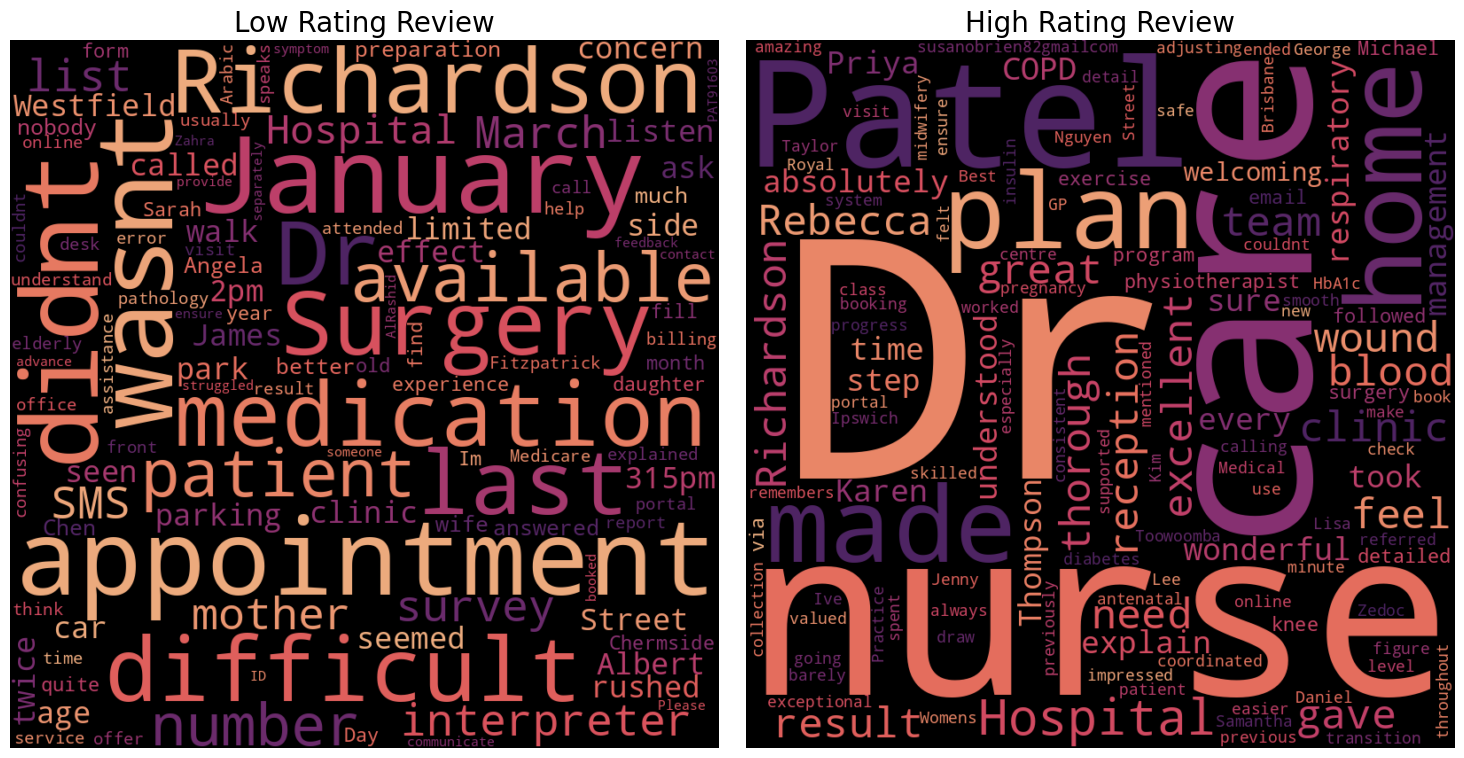

In [66]:
from wordcloud import WordCloud

data_low = df[(df['rating']=='1 star') | (df['rating']=='2 stars')]
data_high = df[(df['rating']=='5 stars') | (df['rating']=='4 stars')]

combined_text_low = ' '.join(data_low['normalized_text'])
combined_text_high = ' '.join(data_high['normalized_text'])


# create a word cloud using the combined text
wordcloud_low = WordCloud(width = 800, height = 800,
                            background_color ='black',
                            colormap = 'flare',
                            min_font_size = 15).generate(combined_text_low)

wordcloud_high = WordCloud(width = 800, height = 800,
                            background_color ='black',
                            colormap = 'flare',
                            min_font_size = 15).generate(combined_text_high)

# plot the WordCloud image
fig, ax = plt.subplots(1, 2, figsize=(15, 15))

ax[0].imshow(wordcloud_low, interpolation='bilinear')
ax[0].set_title('Low Rating Review', fontsize=20)
ax[0].axis('off')

ax[1].imshow(wordcloud_high, interpolation='bilinear')
ax[1].set_title('High Rating Review', fontsize=20)
ax[1].axis('off')


plt.tight_layout(pad=2)
plt.show()

# Sentiment Analysis Using DistilBert-based Amazon-reviews model 

In [67]:
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification

In [68]:
# load tokenizer and model, create trainer
MODEL = "sohan-ai/sentiment-analysis-model-amazon-reviews"
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
model = DistilBertForSequenceClassification.from_pretrained(MODEL)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/646 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

In [69]:
def sentiment_analysis(text):
    try:
        # Ensure the text is a string
        text = str(text)
        inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=512)
        # Make prediction
        outputs = model(**inputs)
        predicted_label = 'positive' if outputs.logits.argmax().item() == 1 else 'negative'
        return predicted_label
    except Exception as e:
        print(f"Error processing text: {text}. Error: {e}")
        return 'error'

In [70]:
# insert a new column 'label' contains the predicted label from the sentiment analysis using pre-trained model from HuggingFace
df['label'] = df['text'].apply(lambda x: sentiment_analysis(x))

In [72]:
# distribution of the positive and negative sentiment by the variation of the Amazon Alexa
fig = px.sunburst(df, 
                  path=['topic','label'], 
                  color='label', 
                  color_discrete_map={'positive': 'green', 'negative': 'red'}, 
                  width=1000, height=900, 
                  template='gridon', 
                  title='Positive & Negatve Sentiment for Different Topic of Customer Feedback')

In [73]:
# Update traces to show label, value (count), and percentage
fig.update_traces(
    textinfo="label+value+percent parent",
    hovertemplate='<b>%{label}</b><br>Count: %{value}<br>Percent of Category: %{percentParent:.1%}'
)

fig.show(renderer="iframe") # Using iframe for Kaggle compatibility

In [74]:
# distribution of the positive and negative sentiment by the variation of the Amazon Alexa
fig = px.sunburst(df, 
                  path=['topic','rating'], 
                  color='rating', 
                  color_discrete_map={'5 stars': 'green', '4 stars': 'green', '3 stars': 'grey', '2 stars': 'red', '1 star': 'red'}, 
                  width=1000, height=900, 
                  template='gridon', 
                  title='high-rating & low-rating Sentiment for Different Topic of Customer Feedback')

In [75]:
# Update traces to show label, value (count), and percentage
fig.update_traces(
    textinfo="label+value+percent parent",
    hovertemplate='<b>%{label}</b><br>Count: %{value}<br>Percent of Category: %{percentParent:.1%}'
)

fig.show(renderer="iframe") # Using iframe for Kaggle compatibility

In [76]:
# distribution of positive and negative sentiment in different rating review
df['rating'] = df['rating'].astype(str)

fig = px.bar(df, 
             x='rating', 
             color='label', 
             barmode='group', 
             width=800, height=600, 
             template='gridon', 
             title='Positive & Negative Sentiment in Different Rating Reviews')

fig.update_layout(
    xaxis = dict(
        title = 'Review Rating'
    ),
    yaxis = dict(
        title = 'Count'
    )
)

fig.show()

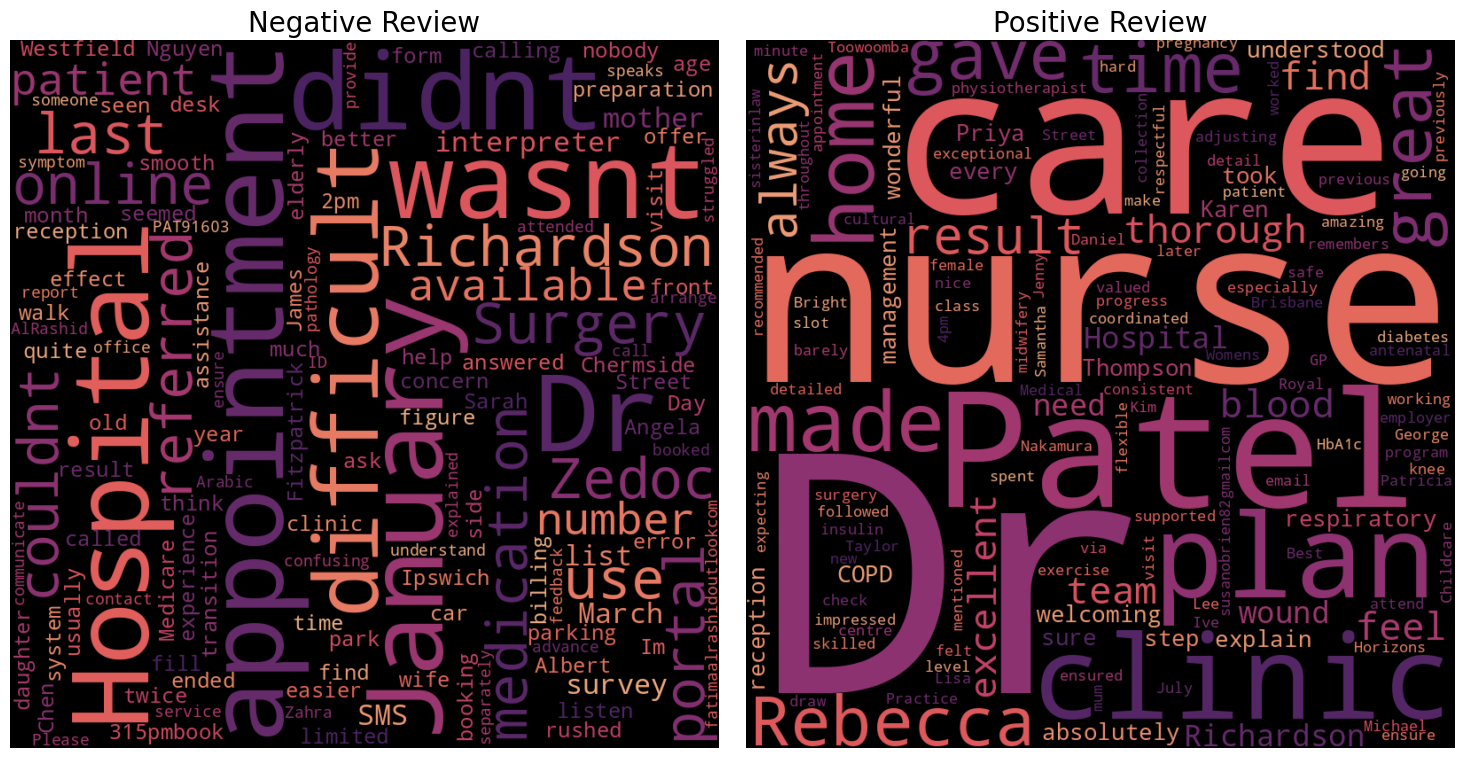

In [77]:
# visualization of keywords in negative and positive sentiment via wordcloud
data_negative = df[df['label']=='negative']
data_positive = df[df['label']=='positive']

combined_text_neg = ' '.join(data_negative['normalized_text'])
combined_text_pos = ' '.join(data_positive['normalized_text'])


# create a word cloud using the combined text
wordcloud_neg = WordCloud(width = 800, height = 800,
                            background_color ='black',
                            colormap = 'flare',
                            min_font_size = 15).generate(combined_text_neg)

wordcloud_pos = WordCloud(width = 800, height = 800,
                            background_color ='black',
                            colormap = 'flare',
                            min_font_size = 15).generate(combined_text_pos)

# plot the WordCloud image
fig, ax = plt.subplots(1, 2, figsize=(15, 15))

ax[0].imshow(wordcloud_neg, interpolation='bilinear')
ax[0].set_title('Negative Review', fontsize=20)
ax[0].axis('off')

ax[1].imshow(wordcloud_pos, interpolation='bilinear')
ax[1].set_title('Positive Review', fontsize=20)
ax[1].axis('off')


plt.tight_layout(pad=2)
plt.show()